# Aggregation Level and Match Analysis: Modeling

This notebook demonstrates how the **aggregation level** at which football (soccer) event data are analysed changes the estimated associations between performance indicators (PIs) and match success — a form of *noncollapsibility* described in the accompanying manuscript.

## Data

**StatsBomb open data** — 1. Bundesliga 2015/16 season, 306 matches, ≈ 600 000 events (loaded via [statsbombpy](https://github.com/statsbomb/statsbombpy)).

## Four Aggregation Levels

| # | Level | Unit of analysis | N (approx.) | Success criterion |
|---|-------|-----------------|-------------|-------------------|
| 1 | Season | Team × season | 18 rows | Rank category (relegated → Champions League) |
| 2 | Match | Team × match | 612 rows | Match result (away win / draw / home win) |
| 3 | Scoreline | Team × scoreline segment | ~2 000 rows | Next goal scorer |
| 4 | Possession | Team × possession sequence | ~60 000 rows | Next goal scorer |

Each level fits an **ordered probit** model with a standardised PI difference as the sole predictor (plus match-status covariates at the scoreline and possession levels).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import seaborn.objects as so
from statsbombpy import sb

In [3]:
# Make Jupyter store Matplotlib outputs as SVG (vector)
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')       # or: set_matplotlib_formats('svg', 'pdf')

# Optional: keep text as real text (not paths) in SVGs
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'


In [4]:
import statsmodels.api as sm
import scipy.stats as stats

from statsmodels.miscmodels.ordinal_model import OrderedModel

## Performance Indicators

The following 17 PIs are extracted from event data. At each aggregation level, the *difference* between the home and away team (or team and opponent) is computed and z-standardised before entering the model.


In [5]:
cols = [
    'match_id', 'period', 'minute', 'second', 'timestamp', 'id', 'index', 'type', 'player', 'team', 'play_pattern', 'possession', 'possession_team',
    'under_pressure', 'tactics', 'duration', 'player_id', 'position', 'possession_team_id', 'team_id',
    'home_team', 'away_team', 'home_goals_ft', 'away_goals_ft', 'match_week',
    'dribble_outcome', 'duel_outcome', 'duel_type', 'location', 'pass_cross', 'pass_end_location', 
    'pass_height', 'pass_length', 'pass_outcome',  'pass_angle', 'pass_through_ball', 'pass_type', 
    'shot_outcome', 'shot_statsbomb_xg', 'shot_type'
]
performance_indicators = [
    'xg', 'shots',
    'passes', 'highpasses', 'groundpasses', 'pressuredpasses', 'pass_length',
    'crosses', 'dribbles', 
    'tackles', 'tackles_success', 'interceptions', 'pressures', 'blocks', 'fouls',
    'counterattacks'
]

## Four Aggregation Levels — Overview

| Level | Unit | N (approx.) | Success criterion | Notes |
|-------|------|-------------|-------------------|-------|
| Season | Team × season | 18 | Rank category (0 = relegated, 3 = CL) | PIs summed over all 34 match-days |
| Match | Team × match | 612 | Match result (0 = away win, 1 = draw, 2 = home win) | PIs summed for full match |
| Scoreline | Team × scoreline segment | ~2 000 | Next goal (0 = away, 1 = none, 2 = home) | Normalised per-90 min; segments > 60 s only |
| Possession | Team × possession | ~60 000 | Next goal (0 = away, 1 = none, 2 = home) | Normalised per-90 min; possessions > 10 s only |

At the scoreline and possession levels, **match-status** covariates (home leading / away leading vs draw) are added to control for the systematic changes in team behaviour driven by the current score.


## Outcome Variables

| Level | Column | Values | Interpretation |
|-------|--------|--------|----------------|
| Season | `rank_category` | 0 (relegated) – 3 (Champions League) | Higher = better season outcome |
| Match | `match_outcome` | 0 (away win), 1 (draw), 2 (home win) | Home-team perspective |
| Scoreline | `next_goal` | 0 (away), 1 (none), 2 (home) | Which team scores next |
| Possession | `next_goal` | 0 (away), 1 (none), 2 (home) | Same as scoreline level |


## Load Processed Data

In [ ]:
df_seasonlevel = pd.read_csv('../data/_df_seasonlevel.csv')
df_matchlevel = pd.read_csv('../data/df_matchlevel.csv')
df_scorelinelevel = pd.read_csv('../data/df_scorelinelevel.csv')
df_possessionlevel = pd.read_csv('../data/df_possessionlevel.csv')

## Ordered Probit Model and Average Marginal Effects

We use an **ordered probit** model (latent-variable formulation with K−1 thresholds) from `statsmodels.miscmodels.ordinal_model.OrderedModel`. The predictor in all models is **`pi_diff`**: the home-minus-away (or team-minus-opponent) standardised PI difference.

At the scoreline and possession levels, two **match-status** dummies (`match_status_away_leading`, `match_status_home_leading`, draw as reference) are added to control for the mechanical influence of the current score on team behaviour.

**Average Marginal Effects (AMEs)** give the average partial derivative of P(y = k) with respect to each predictor across all observations — a probability-scale interpretation of each coefficient.


In [20]:
from scipy.stats import norm
from scipy.special import expit
from scipy import stats as scipy_stats

def ordered_model_ame(fitted_model, X=None, colnames=None):
    """
    Average Marginal Effects (AMEs) for statsmodels OrderedModel.

    Parameters
    ----------
    fitted_model : OrderedModelResults
    X : array-like (n_obs, p). Defaults to fitted_model.model.exog.
    colnames : list[str]. Defaults to model exog_names.

    Returns
    -------
    pd.DataFrame (p, K): AME for each predictor and outcome category.
    """
    if X is None:
        X = fitted_model.model.exog
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n, p = X.shape
    K = fitted_model.model.k_levels
    params = np.asarray(fitted_model.params)
    beta = params[:p]
    taus = params[p:p + (K - 1)]
    if colnames is None:
        colnames = list(getattr(fitted_model.model, 'exog_names', [f'x{j}' for j in range(p)]))[:p]
    elif isinstance(colnames, str):
        colnames = [colnames]
    assert len(colnames) == p, 'Length of colnames must match number of predictors.'
    # statsmodels stores distr as a scipy.stats distribution object, not a string
    distr = fitted_model.model.distr
    if distr is scipy_stats.norm:
        f = norm.pdf
    elif distr is scipy_stats.logistic:
        f = lambda z: expit(z) * (1.0 - expit(z))
    else:
        raise ValueError("Unsupported distribution: expected scipy.stats.norm (probit) or scipy.stats.logistic (logit).")
    xb = X @ beta
    dP_dxb = np.zeros((n, K))
    dP_dxb[:, 0] = -f(taus[0] - xb)
    for k in range(1, K - 1):
        dP_dxb[:, k] = f(taus[k - 1] - xb) - f(taus[k] - xb)
    dP_dxb[:, K - 1] = f(taus[-1] - xb)
    ame = np.vstack([(dP_dxb * beta[j]).mean(axis=0) for j in range(p)])
    return pd.DataFrame(ame, index=colnames, columns=[f'P(y={k})' for k in range(K)])


## Running Models

For each performance indicator, we fit one ordered probit (and one ordered logit) model at each aggregation level. Probit coefficients, confidence intervals, and Average Marginal Effects are stored in `ls_dfs_coefs_probit`.

Loop structure:

1. **Season level** — `pi_diff` only; 4-category outcome (`rank_category`)
2. **Match level** — `pi_diff` only; 3-category outcome (match result)
3. **Scoreline level** — `pi_diff` + match-status dummies; 3-category outcome (next goal)
4. **Possession level** — `pi_diff` + match-status dummies; 3-category outcome (next goal)


In [22]:
ls_dfs_coefs_logit = []
ls_dfs_coefs_probit = []
for pi in performance_indicators:

    ls_levels = ['season_level', 'match_level', 'scoreline_level', 'possession_level']
    ls_level_dfs = [df_season, df_matchlevel, df_scorelinelevel, df_possessionlevel]

    for level, level_df in zip(ls_levels, ls_level_dfs):
        if level == 'season_level':
            level_df['pi_diff'] = level_df[pi + '_diff']
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            predictors = ['pi_diff']
            X = level_df[predictors]
            y = level_df['outcome_ordered'].values

        elif level == 'match_level':
            level_df['pi_diff'] = level_df['home_' + pi + '_scaled'] - level_df['away_' + pi + '_scaled']
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            predictors = ['pi_diff']
            X = level_df[predictors]
            y = level_df['outcome_ordered'].values

        elif level == 'scoreline_level' or level == 'possession_level':
            level_df['pi_diff'] = level_df['home_' + pi + '_90_scaled'] - level_df['away_' + pi + '_90_scaled']
            level_df['pi_diff'] = (level_df['pi_diff'] - level_df['pi_diff'].mean()) / level_df['pi_diff'].std()
            dummies_matchstatus = pd.get_dummies(level_df['match_status'], prefix='match_status', drop_first=False).drop('match_status_draw', axis=1) * 1
            X = pd.concat([level_df[['pi_diff']], dummies_matchstatus], axis=1)
            y = level_df['outcome_ordered'].values

        mod_probit = OrderedModel(
            y, X, distr='probit'
        ).fit(method='bfgs', disp=False)

        mod_logit = OrderedModel(
            y, X, distr='logit'
        ).fit(method='bfgs', disp=False)

        # logit coefficients
        n_pred = X.shape[1]
        ci_logit = np.asarray(mod_logit.conf_int())
        df_coefs_logit = pd.DataFrame({
            'coefficients': np.asarray(mod_logit.params)[:n_pred],
            'confint_upper': ci_logit[:n_pred, 1],
            'confint_lower': ci_logit[:n_pred, 0],
        }, index=list(X.columns))
        df_coefs_logit['Odds Ratio'] = np.exp(df_coefs_logit['coefficients'])
        df_coefs_logit['indicator'] = pi
        df_coefs_logit['level'] = level
        ls_dfs_coefs_logit.append(df_coefs_logit)

        # probit coefficients + AMEs
        ci_probit = np.asarray(mod_probit.conf_int())
        df_coefs_probit = pd.DataFrame({
            'coefficients': np.asarray(mod_probit.params)[:n_pred],
            'confint_upper': ci_probit[:n_pred, 1],
            'confint_lower': ci_probit[:n_pred, 0],
        }, index=list(X.columns))
        ame_df = ordered_model_ame(mod_probit, X, colnames=list(X.columns))
        df_coefs_probit = pd.concat([df_coefs_probit, ame_df], axis=1)
        df_coefs_probit['indicator'] = pi
        df_coefs_probit['level'] = level
        ls_dfs_coefs_probit.append(df_coefs_probit)


ValueError: Unsupported distribution: expected 'probit' or 'logit'.

In [23]:
mod_probit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                      y   Log-Likelihood:                -14.673
Model:                   OrderedModel   AIC:                             37.35
Method:            Maximum Likelihood   BIC:                             40.91
Date:                Fri, 27 Feb 2026                                         
Time:                        19:42:31                                         
No. Observations:                  18                                         
Df Residuals:                      14                                         
Df Model:                           1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
pi_diff        2.2926      0.844      2.715      0.007       0.638       3.947
0/1           -1.9982      0.647     -3.089      0.002      -3.266      -0.730
1/2            0.7348      0.320      2.296      0.022       0.108       1.362
2/3           -0.1048      0.515     -0.203      0.839      -1.115       0.905
==============================================================================
"""

In [197]:
df_coefs = pd.concat(ls_dfs_coefs_probit, axis=0).round(3).reset_index(names='param')


## Results

The coefficient plot below shows the probit coefficient for `pi_diff` (and its 95 % CI) at each aggregation level for each performance indicator. A positive coefficient indicates that outperforming the opponent on this PI is associated with a better outcome.

Coefficients that shift systematically across levels reveal **noncollapsibility**: the same PI–success association changes in magnitude or direction depending on temporal granularity.


In [198]:
df_coefs[~df_coefs['param'].isin(['match_status_away_leading', 'match_status_home_leading'])].drop('param', axis=1).set_index(['level', 'indicator']).unstack().sort_index(axis=1, level=1)

,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper,coefficients,...,confint_upper,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper,coefficients,confint_lower,confint_upper
indicator,blocks,blocks,blocks,counterattacks,counterattacks,counterattacks,crosses,crosses,crosses,dribbles,...,shots,tackles,tackles,tackles,tackles_success,tackles_success,tackles_success,xg,xg,xg
level,,,,,,,,,,,,,,,,,,,,,
match_level,-0.018,-0.147,0.111,0.181,0.043,0.319,-0.023,-0.152,0.106,0.251,...,0.461,-0.095,-0.224,0.034,0.033,-0.097,0.162,0.897,0.709,1.084
possession_level,-0.287,-0.302,-0.272,0.114,0.100,0.127,0.357,0.342,0.372,0.207,...,97.833,-0.014,-0.030,0.001,0.076,0.061,0.092,622.700,511.116,734.284
scoreline_level,-0.174,-0.243,-0.105,0.070,-0.001,0.141,0.348,0.275,0.422,0.194,...,0.295,-0.097,-0.164,-0.030,-0.003,-0.070,0.063,0.090,0.020,0.160
season_level,-0.559,-1.154,0.037,0.205,-0.310,0.720,0.341,-0.218,0.901,0.858,...,1.543,-0.692,-1.297,-0.086,-0.591,-1.160,-0.021,2.293,0.638,3.947


In [32]:
df_analysis = df_coefs[~df_coefs['param'].isin(['match_status_away_leading', 'match_status_home_leading'])].drop('param', axis=1).copy()

NameError: name 'df_coefs' is not defined

In [33]:
ls_indicators_plot = [
    #'goals', 'shots',
      'passes', 'highpasses', 'groundpasses', 'pressuredpasses', 'crosses', 'dribbles',
    #'pass_length', 'tackles', 'tackles_success',
    'interceptions',
     # 'pressures', 'blocks', 'fouls', 'counterattacks'
]

names_indicators_plot = [
 #   'Goals', 'Shots',
    'Passes', 'High Passes', 'Ground Passes', 'Pressured Passes', 'Crosses', 'Dribbles',
    #'Pass Length', 'Tackles', 'Tackles Success',
    'Interceptions',
    # 'Pressures', 'Blocks', 'Fouls', 'Counterattacks'
]

df_plot = df_analysis.loc[
    (df_analysis['indicator'].isin(ls_indicators_plot)) & (df_analysis['level'] != 'possession_level')
].copy()

df_plot['Indicator'] = df_plot['indicator'].map(dict(zip(ls_indicators_plot, names_indicators_plot)))

df_plot['Level'] = (
    df_plot['level']
    .str.replace('_level', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
    )



NameError: name 'df_analysis' is not defined

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import pandas as pd

# Create a fixed palette mapping for all possible Level values
def create_level_palette(df, col="Level"):
    unique_levels = sorted(df[col].unique())  # consistent order
    base_palette = sns.color_palette("colorblind", n_colors=len(unique_levels))
    return dict(zip(unique_levels, base_palette))

def plot_coefficients(df_plot, palette):
    # Clean up 'level' column for plotting
    df_plot = df_plot.copy()


    # ggplot-like theme
    sns.set_theme(style="whitegrid", font_scale=1.1)
    plt.rcParams.update({
        "axes.edgecolor": "0.8",
        "axes.linewidth": 0.8,
        "grid.color": "0.9",
        "grid.linestyle": "-",
        "axes.spines.top": False,
        "axes.spines.right": False
    })

    # Keep order for indicators
    df_plot["Indicator"] = pd.Categorical(
        df_plot["Indicator"],
        ordered=True,
        categories=df_plot["Indicator"].unique()
    )

    # Build plot
    p = (
        so.Plot(
            df_plot,
            x="Indicator",
            y="coefficients",
            color="Level",
            ymin="confint_lower",
            ymax="confint_upper"
        )
        .scale(color=palette)   # FIXED PALETTE HERE
        .add(so.Range(), so.Dodge())
        .add(so.Dot(), so.Dodge())
        .label(x="Indicator", y="Coefficient", color="Level")
    )

    fig = plt.figure(figsize=(9, 5))
    p.on(fig).plot()
    plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Performance Indicator")
    plt.ylabel("Coefficient [95% CI]")
    plt.grid(True, linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()


In [35]:
#| label: fig-coefficients-season
#| fig-cap: "Coefficients of Probit Model for Performance Indicators Across Aggregation Levels"
#| fig-width: 5
#| fig-height: 4

full_palette = create_level_palette(df_plot)

# Plot all levels
plot_coefficients(df_plot, full_palette)

# Plot excluding one level, but colors stay consistent


NameError: name 'df_plot' is not defined

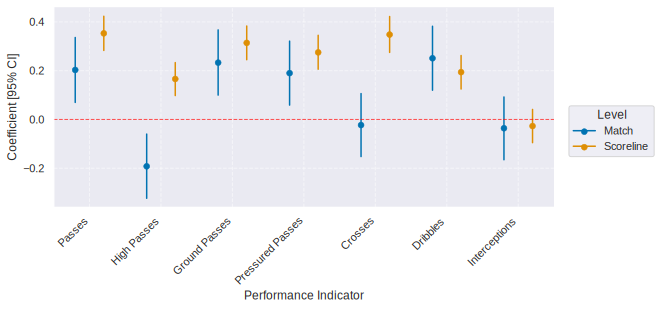

In [307]:
#| label: fig-coefficients-noseason
#| fig-cap: "Coefficients of Probit Model for Performance Indicators Across Aggregation Levels"
#| fig-width: 5
#| fig-height: 4
df_plot_noseason = df_plot[df_plot.level != 'season_level'].copy()

plot_coefficients(df_plot_noseason, full_palette)

### Effect of Match Status on Behaviour

The table below shows the mean home-minus-away PI difference by match-status category. Teams that are *leading* tend to play differently from teams that are *drawing* or *trailing* — this is why match-status dummies are included as covariates at the scoreline and possession levels.


In [38]:
#| label: tbl-indicators-scoreline
#| tbl-cap: Means of Performance Indicators with Respect to Match Status

ls_dfs_context = []
for pi in ls_indicators_plot:
    df_scorelinelevel[pi + '_diff'] = df_scorelinelevel['home_' + pi] - df_scorelinelevel['away_' + pi]
    ls_dfs_context.append(df_scorelinelevel.groupby('match_status')[pi + '_diff'].mean().round(2))

df_context = pd.concat(ls_dfs_context, axis=1)
df_context.columns = df_context.columns.str.replace('_diff', '').map(dict(zip(ls_indicators_plot, names_indicators_plot)))

df_context.index.name = 'Match Status'
df_context.index = df_context.index.map({
    'away_leading': 'Away Leading',
    'draw': 'Draw',
    'home_leading': 'Home Leading'
})

df_context

,Passes,High Passes,Ground Passes,Pressured Passes,Crosses,Dribbles,Interceptions
Match Status,,,,,,,
Away Leading,16.59,1.97,11.40,0.27,1.61,-0.01,-0.34
Draw,14.21,0.67,12.65,-0.09,0.98,0.54,-0.21
Home Leading,-5.01,-0.53,-2.98,-0.40,-0.42,-0.16,0.31
